# UD Grammar Profiles: Dataset Demo

This notebook demonstrates the **UD Grammar Profiles** dataset, which contains per-treebank grammar profiles extracted from all 336 Universal Dependencies treebanks (`commul/universal_dependencies` on HuggingFace).

Each example represents one UD treebank and contains:
- **Head-direction profiles** per dependency relation
- **Sibling-ordering templates** (word order patterns)
- **Structural statistics** (tree depth, branching factor, projectivity, sentence length)
- **Per-deprel frequency counts**
- **Case feature proportions**
- **Typological metadata** from WALS Chapter 49A

The original script (`data.py`) converts raw treebank profiles into a schema-compliant format with validated `input`/`output` JSON strings and `metadata_*` fields.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

## Load Data

Load the mini demo dataset (10 diverse UD treebanks) from GitHub, with local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c3cfa4-sequential-dependency-distance-anti-corr/main/dataset_iter1_ud_grammar_prof/demo/mini_demo_data.json"

import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded dataset: {data['datasets'][0]['dataset']}")
print(f"Number of examples: {len(data['datasets'][0]['examples'])}")
print(f"Metadata: {json.dumps(data['metadata'], indent=2)}")

Loaded dataset: universal_dependencies_grammar_profiles
Number of examples: 10
Metadata: {
  "source": "commul/universal_dependencies (HuggingFace)",
  "description": "Per-treebank grammar profiles from 336 Universal Dependencies treebanks",
  "version": "1.0",
  "wals_source": "cldf-datasets/wals (GitHub)",
  "ud_version": "2.17",
  "total_treebanks": 10
}


## Configuration

Tunable parameters for the demo processing pipeline.

In [5]:
# --- Config ---
# Maximum number of examples to process (original: all 336 treebanks)
MAX_EXAMPLES = 10  # original: 336

# Number of top language families to display in summary
TOP_N_FAMILIES = 10  # original: 10

# Number of top deprels to show in frequency analysis
TOP_N_DEPRELS = 10  # original: 60

## Convert Raw Rows to Schema-Compliant Examples

Each row is converted so that `input` and `output` are JSON strings, and all `metadata_*` fields are preserved as flat top-level fields.

In [6]:
def convert_row_to_example(row: dict, idx: int) -> dict:
    """Convert one raw treebank row to a schema-compliant example.

    Schema requires:
      - input: string
      - output: string
      - metadata_*: flat metadata fields
    """
    example = {
        "input": json.dumps(row["input"], ensure_ascii=False) if isinstance(row["input"], dict) else row["input"],
        "output": json.dumps(row["output"], ensure_ascii=False) if isinstance(row["output"], dict) else row["output"],
    }
    # Copy all metadata_* fields from the raw row
    for key, value in row.items():
        if key.startswith("metadata_"):
            example[key] = value

    # Add row index metadata
    example["metadata_row_index"] = idx

    return example


# Process examples from the loaded data
raw_examples = data["datasets"][0]["examples"][:MAX_EXAMPLES]
examples = []
for idx, row in enumerate(raw_examples):
    example = convert_row_to_example(row, idx)
    examples.append(example)

print(f"Converted {len(examples)} examples")
# Show first example structure
ex = examples[0]
print(f"\nExample keys: {list(ex.keys())}")
parsed_input = json.loads(ex["input"])
print(f"Input: {json.dumps(parsed_input, indent=2)}")

Converted 10 examples

Example keys: ['input', 'output', 'metadata_fold', 'metadata_modality', 'metadata_wals_49a_value', 'metadata_wals_49a_label', 'metadata_language_family', 'metadata_language_name', 'metadata_row_index']
Input: {
  "treebank_id": "ab_abnc",
  "language_prefix": "ab",
  "iso639_3": "abk"
}


## Validate Examples

Verify that each example has the required fields and correct types, matching the schema specification.

In [7]:
def validate_example(example: dict, idx: int) -> bool:
    """Validate a single example has required fields and correct types."""
    if "input" not in example or not isinstance(example["input"], str):
        print(f"Example {idx}: missing or non-string 'input'")
        return False
    if "output" not in example or not isinstance(example["output"], str):
        print(f"Example {idx}: missing or non-string 'output'")
        return False
    # Verify input is valid JSON
    try:
        parsed_input = json.loads(example["input"])
        if "treebank_id" not in parsed_input:
            print(f"Example {idx}: input missing 'treebank_id'")
            return False
    except json.JSONDecodeError:
        print(f"Example {idx}: input is not valid JSON")
        return False
    # Verify output is valid JSON
    try:
        parsed_output = json.loads(example["output"])
        required_output_keys = [
            "head_direction_profile",
            "sibling_order_templates",
            "structural_stats",
            "deprel_frequency_counts",
            "case_feature_proportion",
        ]
        for key in required_output_keys:
            if key not in parsed_output:
                print(f"Example {idx}: output missing '{key}'")
                return False
    except json.JSONDecodeError:
        print(f"Example {idx}: output is not valid JSON")
        return False
    # Check no disallowed top-level keys
    for key in example:
        if key not in ("input", "output") and not key.startswith("metadata_"):
            print(f"Example {idx}: disallowed key '{key}'")
            return False
    return True


# Validate all examples
valid_count = 0
errors = 0
for idx, ex in enumerate(examples):
    if validate_example(ex, idx):
        valid_count += 1
    else:
        errors += 1

print(f"Validation: {valid_count}/{len(examples)} valid, {errors} errors")

Validation: 10/10 valid, 0 errors


## Summary Statistics

Compute summary statistics over the processed examples: modality distribution, language families, WALS 49A matches, and structural properties.

In [8]:
# Summary statistics (from original data.py)
modalities = {}
families = {}
wals_matched = 0
for ex in examples:
    mod = ex.get("metadata_modality", "unknown")
    modalities[mod] = modalities.get(mod, 0) + 1
    fam = ex.get("metadata_language_family", "unknown")
    families[fam] = families.get(fam, 0) + 1
    if ex.get("metadata_wals_49a_value") is not None:
        wals_matched += 1

print(f"Total examples: {len(examples)}")
print(f"Modalities: {modalities}")
print(f"WALS 49A matched: {wals_matched}/{len(examples)}")
print(f"Language families: {len(families)} distinct")
print("Top families: " + ", ".join(
    f"{k}({v})" for k, v in sorted(families.items(), key=lambda x: -x[1])[:TOP_N_FAMILIES]
))

# Extract structural stats for analysis
struct_rows = []
for ex in examples:
    parsed_input = json.loads(ex["input"])
    parsed_output = json.loads(ex["output"])
    stats = parsed_output["structural_stats"]
    struct_rows.append({
        "treebank_id": parsed_input["treebank_id"],
        "language": ex.get("metadata_language_name", "?"),
        "family": ex.get("metadata_language_family", "?"),
        "modality": ex.get("metadata_modality", "?"),
        "wals_49a": ex.get("metadata_wals_49a_value"),
        "case_proportion": parsed_output["case_feature_proportion"],
        **stats,
    })

df = pd.DataFrame(struct_rows)
print(f"\nStructural statistics table:")
print(df[["treebank_id", "language", "family", "modality", "mean_tree_depth",
          "mean_branching_factor", "proportion_projective", "mean_sentence_length"]].to_string(index=False))

Total examples: 10
Modalities: {'written': 8, 'spoken': 1, 'sign': 1}
WALS 49A matched: 5/10
Language families: 10 distinct
Top families: Northwest Caucasian(1), Afro-Asiatic(1), other(1), Indo-European(1), (1), Arawakan(1), Chibchan(1), Tupian(1), Uto-Aztecan(1), Mande(1)

Structural statistics table:
  treebank_id                        language              family modality  mean_tree_depth  mean_branching_factor  proportion_projective  mean_sentence_length
      ab_abnc                          Abkhaz Northwest Caucasian  written             3.30                   2.61                 0.9810                  8.04
bej_autogramm                            Beja        Afro-Asiatic   spoken             5.53                   2.20                 0.9279                 15.66
      ssp_lse        Lengua de Señas Española               other     sign             2.07                   1.59                 0.9816                  2.85
 af_afribooms                       Afrikaans       Indo

## Visualization

Plot structural properties across treebanks and head-direction profiles to reveal typological patterns.

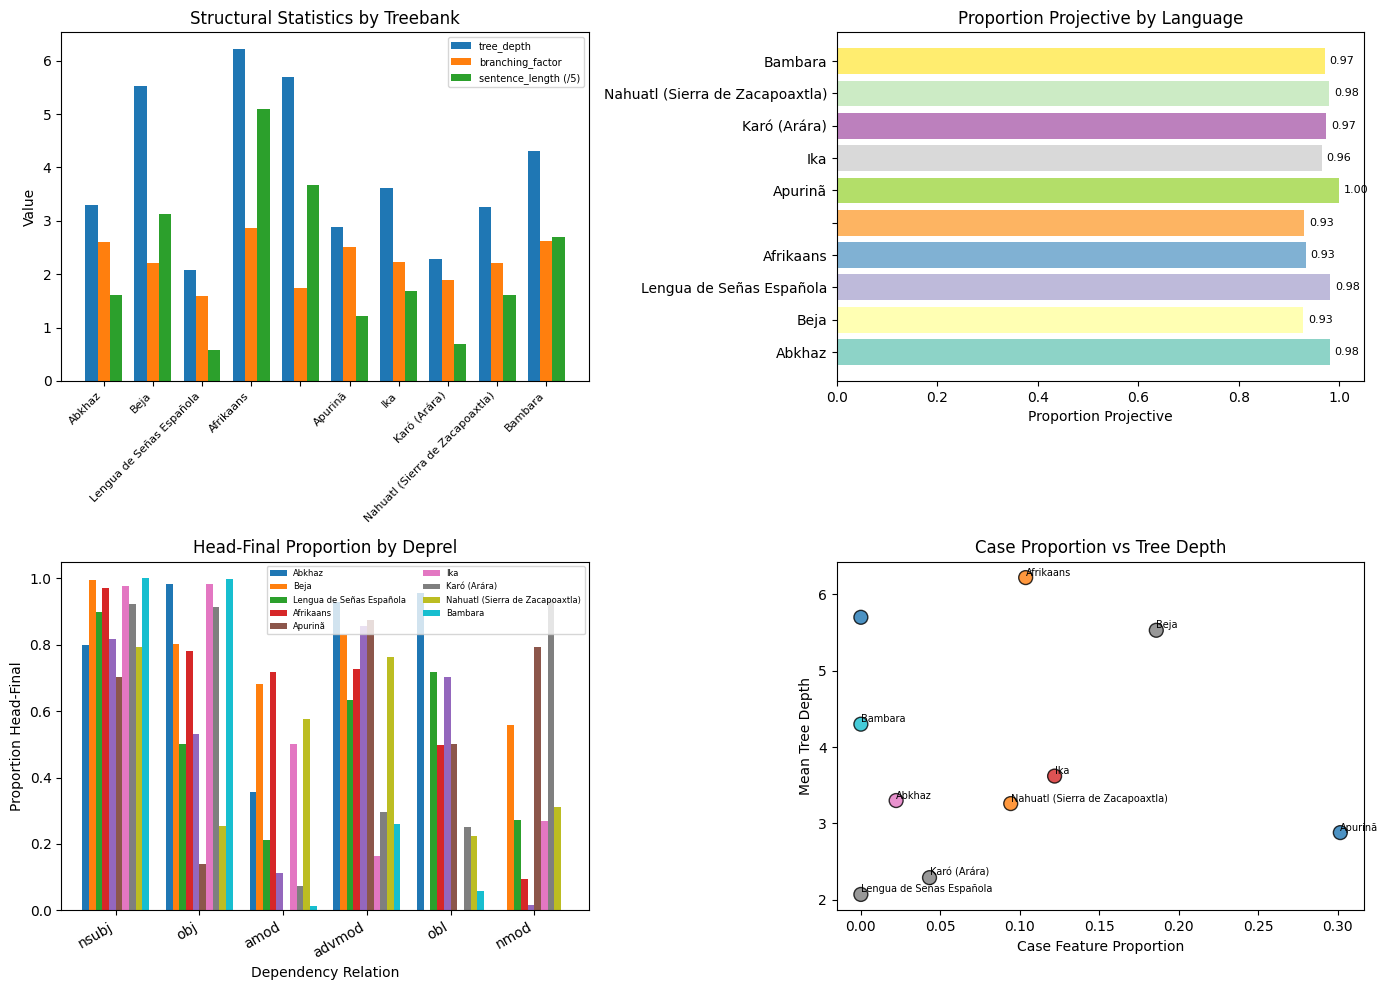

Saved: grammar_profiles_overview.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Structural stats bar chart ---
ax = axes[0, 0]
stats_cols = ["mean_tree_depth", "mean_branching_factor", "mean_sentence_length"]
x = np.arange(len(df))
width = 0.25
for i, col in enumerate(stats_cols):
    vals = df[col].astype(float).values
    # Normalize sentence length to fit same scale
    if col == "mean_sentence_length":
        vals = vals / 5.0
        label = f"{col} (/5)"
    else:
        label = col
    ax.bar(x + i * width, vals, width, label=label.replace("mean_", ""))
ax.set_xticks(x + width)
ax.set_xticklabels(df["language"], rotation=45, ha="right", fontsize=8)
ax.set_title("Structural Statistics by Treebank")
ax.legend(fontsize=7)
ax.set_ylabel("Value")

# --- Plot 2: Proportion projective ---
ax = axes[0, 1]
colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
bars = ax.barh(df["language"], df["proportion_projective"].astype(float), color=colors)
ax.set_xlabel("Proportion Projective")
ax.set_title("Proportion Projective by Language")
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, df["proportion_projective"].astype(float)):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va="center", fontsize=8)

# --- Plot 3: Head-direction profile (proportion head-final for common deprels) ---
ax = axes[1, 0]
common_deprels = ["nsubj", "obj", "amod", "nmod", "advmod", "obl"]
hd_data = {}
for ex in examples:
    parsed_input = json.loads(ex["input"])
    parsed_output = json.loads(ex["output"])
    hdp = parsed_output["head_direction_profile"]
    lang = ex.get("metadata_language_name", "?")
    for dep in common_deprels:
        if dep in hdp:
            if dep not in hd_data:
                hd_data[dep] = {}
            hd_data[dep][lang] = hdp[dep]["prop_head_final"]

hd_df = pd.DataFrame(hd_data).T
if not hd_df.empty:
    hd_df.plot(kind="bar", ax=ax, width=0.8, legend=True)
    ax.set_title("Head-Final Proportion by Deprel")
    ax.set_ylabel("Proportion Head-Final")
    ax.set_xlabel("Dependency Relation")
    ax.legend(fontsize=6, loc="upper right", ncol=2)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

# --- Plot 4: Case feature proportion vs Tree Depth ---
ax = axes[1, 1]
df_wals = df.copy()
ax.scatter(df_wals["case_proportion"].astype(float), df_wals["mean_tree_depth"].astype(float),
           c=[hash(f) % 10 for f in df_wals["family"]], cmap="tab10", s=100, edgecolors="black", alpha=0.8)
for _, row in df_wals.iterrows():
    ax.annotate(row["language"], (float(row["case_proportion"]), float(row["mean_tree_depth"])),
                fontsize=7, ha="left", va="bottom")
ax.set_xlabel("Case Feature Proportion")
ax.set_ylabel("Mean Tree Depth")
ax.set_title("Case Proportion vs Tree Depth")

plt.tight_layout()
plt.savefig("grammar_profiles_overview.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: grammar_profiles_overview.png")